# Fermi-Pasta-Ulam problem

Author: Kevin Schäfers, kschaefers@uni-wuppertal.de
Date: 15.01.2026

---------------------------------------------------

This Jupyter notebook implements the hierarchical splitting methods used in 

*K. Schäfers, M. Günther: A hierarchical splitting approach for N-split ordinary differential equations*

to perform the numerical simulations for the FPU problem. Moreover, this Jupyter notebook contains the scripts with which the numerical results have been obtained. For the numerical results reported in the paper, we have executed this Jupyter notebook with Python version 3.13.0 on a MacBook Pro 2021 with M1 Pro chip.



In [1]:
import numpy as np 
from scipy.integrate import solve_ivp # for the reference solution
import matplotlib.pyplot as plt # for plotting
import time # to measure CPU time
import matplot2tikz # convert pyplot to tikz, see https://github.com/ErwindeGelder/matplot2tikz

We start by specifying the time interval, the number of masses $m$, the parameter $\omega$, and the initial values of the FPU problem.

In [2]:
tspan = [0,220]
m = 3
omega = 50 # omega**2 = 2500
x0 = np.zeros(4*m)
x0[0] = 1.0
x0[m] = 1.0
x0[2*m] = 1.0 
x0[3*m] = 1.0/omega

Definition of the Hamiltonian, as well as its gradient (split into the four partitions we are going to investigate).

In [3]:
def T_s(p): 
    # slow part of the kinetic energy
    m=len(p) // 2
    return 0.5 * np.dot(p[:m],p[:m])

def T_f(p):
    # fast part of the kinetic energy
    m=len(p) // 2
    return 0.5 * np.dot(p[m:],p[m:])

def V_s(q):
    # slow part of the potential energy
    m = len(q) // 2

    expr = (q[0]-q[m])**4
    for i in range(m-1):
        expr += (q[i+1] - q[m+i+1] - q[i] - q[m+i])**4 

    expr += (q[m-1] + q[-1])**4

    return 0.25*expr    

def V_f(q):
    # fast part of the potential energy
    m = len(q) // 2
    return omega**2/2 * np.dot(q[m:],q[m:])

def H(p,q):
    # total energy / Hamiltonian
    return T_s(p) + T_f(p) + V_s(q) + V_f(q)

def f1(p):
    # dT_s/dp
    m = len(p) // 2
    res = np.zeros(2*m)
    res[:m] = p[:m]
    return res

def f2(p):
    # dT_f/dp
    m = len(p) // 2
    res = np.zeros(2*m)
    res[m:] = p[m:]
    return res

def f3(q):
    # -dV_s/dq
    m = len(q) // 2
    dp = np.zeros_like(q)
    expr = (q[0] - q[m])**3
    dp[0] = expr 
    dp[m] = -expr
    for i in range(m-1):
        expr = (q[i+1] - q[m+i+1] - q[i] - q[m+i])**3 
        dp[i+1] += expr
        dp[m+i+1] -= expr
        dp[i] -= expr
        dp[m+i] -= expr
    expr = (q[m-1] + q[-1])**3 
    dp[m-1] += expr
    dp[-1] += expr 

    return -dp

def f4(q):
    # -dV_f/dq
    m = len(q) // 2
    res = np.zeros(2*m)
    res[m:] = q[m:]
    return -omega**2 * res

# full right-hand side, used for computing the reference solution:
f = lambda t,x: np.concatenate((f3(x[2*m:]) + f4(x[2*m:]), f1(x[:2*m]) + f2(x[:2*m]))) 

After defining the FPU problem, we can now compute the reference solution.

In [4]:
sol = solve_ivp(
    f,
    tspan, x0,
    method="RK45",
    dense_output=True,
    rtol=1e-12, atol=1e-14
)

We may look at the reference solution of $q_1^{\{\mathfrak{f}\}}(t)$:

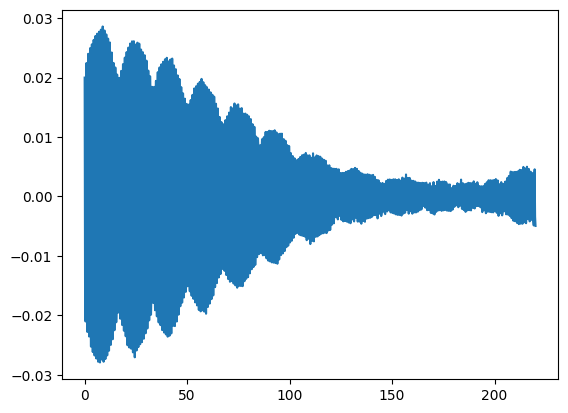

In [5]:
t_eval = np.linspace(tspan[0], tspan[1], 1000)
x_eval = sol.sol(t_eval)  

plt.plot(t_eval,x_eval[3*m,:])
plt.show()

# Implementation of the Hierarchical Splitting Methods 

`ImpulseMethod` - not included in numerical results as focus is on comparison of fourth-order integrators.

In [6]:
def ImpulseMethod(x0,tspan,nsteps,M,reweighting=True):
    """
    Impulse method for the FPU problem with splitting into slow and fast Hamiltonian parts, 
    which are split further into their kinetic and potential parts, respectively.

    For the splitting into the slow and fast Hamiltonian, the Strang splitting is used.
    We start by computing M steps of the fast subsystem with step size h/(2M),
    then a full step of the slow subsystem with step size h,
    and finally another M steps of the fast subsystem with step size h/(2M).

    Both subsystems are solved by the Strang splitting as well: the Hamiltonian of the
    subsystem is split into its kinetic and potential parts, H = T + V. 
    We start by a half step of the potential part with step size h/2,
    then a full step of the kinetic part with step size h,
    and finally another half step of the potential part with step size h/2.

    The resulting method is convergent of second order, time-reversible, and symplectic.

    Inputs:
        x0: initial condition (numpy array of shape (2d,))
        tspan: time interval (tuple (t0,tf))
        nsteps: number of macro time steps (int)
        M: number of micro steps for the fast part of the Hamiltonian (int)
        reweighting: whether to use re-weighting of the multirate factor (bool, default: True)
        
    Outputs:
        t: time grid (numpy array of shape (nsteps+1,))
        x: solution at each time step (numpy array of shape (2d,nsteps+1))
    """

    d = len(x0)//2 

    h = (tspan[1] - tspan[0])/nsteps 
    t = np.linspace(tspan[0],tspan[1],nsteps+1)
    x = np.zeros((len(x0),nsteps+1))
    x[:,0] = x0 

    if reweighting:
        # re-weighting of the multirate factor
        M = int(np.ceil(0.5*M))
    # otherwise, M is used as given

    x[d:,1] = x[d:,0] + h/2 * f1(x[:d,0])
    x[:d,1] = x[:d,0] + h/(4*M) * f4(x[d:,0]) # as we combine subsequent evaluations of f4, we have to place the very first one outside the loop

    for n in range(nsteps):
        # half time step of the fast subsystem by computing M steps of the Strang splitting 
        for m in range(M):
            x[d:,n+1] = x[d:,n+1] + h/(2*M) * f2(x[:d,n+1])
            if m < M-1: 
                # if it's not the last substep, we can combine it with 
                # the first substep of the next iteration to save an evaluation of f4
                x[:d,n+1] = x[:d,n+1] + h/(2*M) * f4(x[d:,n+1])
            else:
                # otherwise, we need to do the last substep separately
                x[:d,n+1] = x[:d,n+1] + h/(4*M) * f4(x[d:,n+1])

        # full time step of the slow subsystem by Strang splitting 
        x[:d,n+1] = x[:d,n+1] + h * f3(x[d:,n+1]) # half step to update the momenta

        # another half time step of the fast subsystem by computing M steps of the Strang splitting 
        x[:d,n+1] = x[:d,n+1] + h/(4*M) * f4(x[d:,n+1]) # again put the first evaluation of f4 outside the loop
        for m in range(M):
            x[d:,n+1] = x[d:,n+1] + h/(2*M) * f2(x[:d,n+1])
            if m < M-1:
                x[:d,n+1] = x[:d,n+1] + h/(2*M) * f4(x[d:,n+1])
            elif n < nsteps-1:
                # if it's not the last macro step, we can re-use the evaluation of f4 for the first update in the next macro step.
                val = f4(x[d:,n+1])
                x[:d,n+1] = x[:d,n+1] + h/(4*M) * val 
                x[:d,n+2] = x[:d,n+1] + h/(4*M) * val # re-use evaluation of f4 and already perform the first substep of the next macro step
                val = f1(x[:d,n+1])
                x[d:,n+1] = x[d:,n+1] + h/2 * val
                x[d:,n+2] = x[d:,n+1] + h/2 * val
            else:
                # if it's the last macro step, we only have to do the final substep here
                x[:d,n+1] = x[:d,n+1] + h/(4*M) * f4(x[d:,n+1])
                x[d:,n+1] = x[d:,n+1] + h/2 * f1(x[:d,n+1])

    return t,x

`YoshidaImpulse` uses a triple-jump composition of the `ImpulseMethod` that has been implemented in the preceeding cell. Instead of calling `ImpulseMethod` three times with step sizes $\gamma_i h$, we directly implement the scheme to merge subsequent evaluations of the same flow, resulting in less flow evaluations while resulting in the same method. 

In the paper, `YoshidaImpulse` is referred to as $\mathtt{Yoshida4}$.

In [7]:
def YoshidaImpulse(x0,tspan,nsteps,M,reweighting=True):
    """
    Yoshidas triple-jump composition using Impulse_method as the base method.
    Instead of using Impulse_method as a black box, we directly implement 
    the steps here to save unneccessary function evaluations whenever possible.

    The resulting method is convergent of fourth order, time-reversible, and symplectic.

    Inputs:
        x0: initial condition (numpy array of shape (2d,))
        tspan: time interval (tuple (t0,tf))            
        nsteps: number of macro time steps (int)
        M: number of micro steps for the fast part of the Hamiltonian (int)
        reweighting: whether to use re-weighting of the multirate factor (bool, default: True)
        
    Outputs:
        t: time grid (numpy array of shape (nsteps+1,))
        x: solution at each time step (numpy array of shape (2d,nsteps+1))          
    """
    d = len(x0)//2 

    h = (tspan[1] - tspan[0])/nsteps 
    t = np.linspace(tspan[0],tspan[1],nsteps+1)
    x = np.zeros((len(x0),nsteps+1))
    x[:,0] = x0 

    # weights for the triple-jump composition
    gamma1 = 1/(2.0 - 2.0**(1/3))
    gamma2 = 1-2*gamma1

    if reweighting:
        mrfactor = int(np.ceil(np.abs(gamma1)*M/2)) # re-weighting of the multirate factor
    else:
        mrfactor = M # use given M without re-weighting
    x[d:,1] = x[d:,0] + gamma1*h/2 * f1(x[:d,0])
    x[:d,1] = x[:d,0] + gamma1*h/(4*mrfactor) * f4(x[d:,0])

    for n in range(nsteps):  
        for m in range(mrfactor):
            x[d:,n+1] = x[d:,n+1] + gamma1*h/(2*mrfactor) * f2(x[:d,n+1])
            if m < mrfactor - 1:
                x[:d,n+1] = x[:d,n+1] + gamma1*h/(2*mrfactor) * f4(x[d:,n+1])
            else:
                x[:d,n+1] = x[:d,n+1] + gamma1*h/(4*mrfactor) * f4(x[d:,n+1])

        x[:d,n+1] = x[:d,n+1] + gamma1*h * f3(x[d:,n+1])

        x[:d,n+1] = x[:d,n+1] + gamma1*h/(4*mrfactor) * f4(x[d:,n+1])
        for m in range(mrfactor):
            x[d:,n+1] = x[d:,n+1] + gamma1*h/(2*mrfactor) * f2(x[:d,n+1])
            if m < mrfactor - 1:
                x[:d,n+1] = x[:d,n+1] + gamma1*h/(2*mrfactor) * f4(x[d:,n+1])
            else:
                val = f4(x[d:,n+1])
                x[:d,n+1] = x[:d,n+1] + gamma1*h/(4*mrfactor) * val

        #--- end of first call of impulse method
        x[d:,n+1] = x[d:,n+1] + (gamma1+gamma2)*h/2 * f1(x[:d,n+1])
        #---

        if reweighting:
            mrfactor = int(np.ceil(np.abs(gamma2)*M/2))
        else:
            mrfactor = M
        x[:d,n+1] = x[:d,n+1] + gamma2*h/(4*mrfactor) * val
        for m in range(mrfactor):
            x[d:,n+1] = x[d:,n+1] + gamma2*h/(2*mrfactor) * f2(x[:d,n+1])
            if m < mrfactor - 1:
                x[:d,n+1] = x[:d,n+1] + gamma2*h/(2*mrfactor) * f4(x[d:,n+1])
            else:
                x[:d,n+1] = x[:d,n+1] + gamma2*h/(4*mrfactor) * f4(x[d:,n+1])

        x[:d,n+1] = x[:d,n+1] + gamma2*h * f3(x[d:,n+1])

        x[:d,n+1] = x[:d,n+1] + gamma2*h/(4*mrfactor) * f4(x[d:,n+1])
        for m in range(mrfactor):
            x[d:,n+1] = x[d:,n+1] + gamma2*h/(2*mrfactor) * f2(x[:d,n+1])
            if m < mrfactor - 1:
                x[:d,n+1] = x[:d,n+1] + gamma2*h/(2*mrfactor) * f4(x[d:,n+1])
            else:
                val = f4(x[d:,n+1])
                x[:d,n+1] = x[:d,n+1] + gamma2*h/(4*mrfactor) * val

        #--- end of second call of impulse method
        x[d:,n+1] = x[d:,n+1] + (gamma2+gamma1)*h/2 * f1(x[:d,n+1])
        #---

        if reweighting:
            mrfactor = int(np.ceil(np.abs(gamma1)*M/2))
        else:
            mrfactor = M
        x[:d,n+1] = x[:d,n+1] + gamma1*h/(4*mrfactor) * val
        for m in range(mrfactor):
            x[d:,n+1] = x[d:,n+1] + gamma1*h/(2*mrfactor) * f2(x[:d,n+1])
            if m < mrfactor - 1:
                x[:d,n+1] = x[:d,n+1] + gamma1*h/(2*mrfactor) * f4(x[d:,n+1])
            else:
                x[:d,n+1] = x[:d,n+1] + gamma1*h/(4*mrfactor) * f4(x[d:,n+1])

        x[:d,n+1] = x[:d,n+1] + gamma1*h * f3(x[d:,n+1])

        x[:d,n+1] = x[:d,n+1] + gamma1*h/(4*mrfactor) * f4(x[d:,n+1])
        for m in range(mrfactor):
            x[d:,n+1] = x[d:,n+1] + gamma1*h/(2*mrfactor) * f2(x[:d,n+1])
            if m < mrfactor - 1:
                x[:d,n+1] = x[:d,n+1] + gamma1*h/(2*mrfactor) * f4(x[d:,n+1])
            elif n < nsteps - 1:
                val = f4(x[d:,n+1])
                x[:d,n+1] = x[:d,n+1] + gamma1*h/(4*mrfactor) * val
                x[:d,n+2] = x[:d,n+1] + gamma1*h/(4*mrfactor) * val # re-use evaluation of f4 and already perform the first substep of the next macro step
                val = f1(x[:d,n+1])
                x[d:,n+1] = x[d:,n+1] + gamma1*h/2 * val
                x[d:,n+2] = x[d:,n+1] + gamma1*h/2 * val
            else:
                x[:d,n+1] = x[:d,n+1] + gamma1*h/(4*mrfactor) * f4(x[d:,n+1])
                x[d:,n+1] = x[d:,n+1] + gamma1*h/2 * f1(x[:d,n+1])

    return t,x

Implementation of the `HierarchicalOMF4` method that uses the `OMF4` splitting method in nodes $\mathcal{H}$ and $\mathcal{H}^{\{\mathfrak{f}\}}$.

In the paper, the `HierarchicalOMF4` method is referred to as $\mathtt{HOMF4}$.


In [8]:
def HierarchicalOMF4(x0,tspan,nsteps,mrfactor,reweighting=True):
    """
    Fourth-order optimized method with nested integration for the FPU problem 
    with splitting into slow and fast Hamiltonian parts.
    Both Hamiltonian parts are further split into their kinetic and potential parts, respectively.
    For all three inner nodes, the splitting method OMF4 for two-split systems is used.

    When splitting into fast and slow Hamiltonian, the OMF4 calls for the fast subsystem are performed 
    by computing M micro steps

    Inputs:     
        x0: initial condition (numpy array of shape (2d,))
        tspan: time interval (tuple (t0,tf))            
        nsteps: number of macro time steps (int)
        mrfactor: factor to determine the number of micro steps for the fast part of the Hamiltonian 
                   as M = mrfactor * max(|a2|,|a3|), where a2 and a3 are the coefficients of OMF4
        reweighting: whether to use re-weighting of the multirate factor (bool, default: True)

    Outputs:        
        t: time grid (numpy array of shape (nsteps+1,))
        x: solution at each time step (numpy array of shape (2d,nsteps+1))
    """

    def OMF4_core_step(f,g,x,h):
        d = len(x)//2
        a2 = 0.253978510841060
        a3 = -0.032302867652700
        b1 = 0.083983152628767
        b2 = 0.682236533571909

        x[d:] += a2*h * f(x[:d])
        x[:d] += b2*h * g(x[d:])   
        x[d:] += a3*h * f(x[:d])
        x[:d] += (0.5 - b1 - b2)*h * g(x[d:])
        x[d:] += (1 - 2*a2 - 2*a3)*h * f(x[:d])
        x[:d] += (0.5 - b1 - b2)*h * g(x[d:])
        x[d:] += a3*h * f(x[:d])
        x[:d] += b2*h * g(x[d:])
        x[d:] += a2*h * f(x[:d])

        return x

    d = len(x0)//2 

    h = (tspan[1] - tspan[0])/nsteps 
    t = np.linspace(tspan[0],tspan[1],nsteps+1)
    x = np.zeros((len(x0),nsteps+1))
    x[:,0] = x0 

    a = np.array([0.0,0.253978510841060,-0.032302867652700,1 - 2*0.253978510841060 - 2*(-0.032302867652700),-0.032302867652700,0.253978510841060])
    b = np.array([0.083983152628767,0.682236533571909,0.5-0.083983152628767-0.682236533571909,0.5-0.083983152628767-0.682236533571909,0.682236533571909,0.083983152628767])
    s = len(a)

    x[:d,1] = x[:d,0] + b[0]*h * f3(x[d:,0])
    x[d:,1] = x[d:,0]

    for n in range(nsteps):
        for j in range(s):
            if a[j] != 0:
                x[d:,n+1] = x[d:,n+1] + a[j]*h * f1(x[:d,n+1])
                if reweighting:
                    # re-weighting of the multirate factor
                    M = int(np.ceil(np.abs(a[j])*mrfactor))
                else:
                    # no re-weighting, always use the same number of micro steps
                    M = mrfactor
                x[:d,n+1] = x[:d,n+1] + a[j]*b[0]*h/M * f4(x[d:,n+1])
                for m in range(M):
                    x[:,n+1] = OMF4_core_step(f2,f4,x[:,n+1],a[j]*h/M)
                    if m < M-1:
                        x[:d,n+1] = x[:d,n+1] + 2*a[j]*b[0]*h/M * f4(x[d:,n+1])
                    else:
                        x[:d,n+1] = x[:d,n+1] + a[j]*b[0]*h/M * f4(x[d:,n+1])

            if j == s-1:
                if n < nsteps-1:
                    val = f3(x[d:,n+1])
                    x[:d,n+1] = x[:d,n+1] + b[j]*h * val
                    x[:d,n+2] = x[:d,n+1] + b[j]*h * val # re-use evaluation of f3 and already perform the first step of the next macro step
                    x[d:,n+2] = x[d:,n+1]
                else:
                    x[:d,n+1] = x[:d,n+1] + b[j]*h * f3(x[d:,n+1]) 
            elif j > 0:
                x[:d,n+1] = x[:d,n+1] + b[j]*h * f3(x[d:,n+1]) 

    return t,x

It follows the implementation of the `COMP4` method that uses the `OMF4` splitting method in the root node $\mathcal{H}$, but the `Strang` splitting in the node $\mathcal{H}^{\{\mathfrak{f}\}}$. Due to the Strang splitting, the overall hierarchical splitting method is only covergent of second order. 

We use this setup to highlight the concept of computational order: the order reduction comes from the sub-tree of the fast Hamiltonian. For sufficiently large multirate factor $M$ attached to the edge connecting the sub-tree to the remainder tree, the `COMP4` method achieves a *computational order* of four.

In [9]:
def COMP4(x0,tspan,nsteps,mrfactor,reweighting=True):
    """
    Fourth-order optimized method with nested integration for the FPU problem 
    with splitting into slow and fast Hamiltonian parts.
    Both Hamiltonian parts are further split into their kinetic and potential parts, respectively.
    For all three inner nodes, the splitting method OMF4 for two-split systems is used.

    When splitting into fast and slow Hamiltonian, the OMF4 calls for the fast subsystem are performed 
    by computing M micro steps

    Inputs:     
        x0: initial condition (numpy array of shape (2d,))
        tspan: time interval (tuple (t0,tf))            
        nsteps: number of macro time steps (int)
        mrfactor: factor to determine the number of micro steps for the fast part of the Hamiltonian 
                   as M = mrfactor * max(|a2|,|a3|), where a2 and a3 are the coefficients of OMF4
        reweighting: whether to use re-weighting of the multirate factor (bool, default: True)

    Outputs:        
        t: time grid (numpy array of shape (nsteps+1,))
        x: solution at each time step (numpy array of shape (2d,nsteps+1))
    """

    def OMF4_core_step(f,g,x,h):
        d = len(x)//2
        a2 = 0.253978510841060
        a3 = -0.032302867652700
        b1 = 0.083983152628767
        b2 = 0.682236533571909

        x[d:] += a2*h * f(x[:d])
        x[:d] += b2*h * g(x[d:])   
        x[d:] += a3*h * f(x[:d])
        x[:d] += (0.5 - b1 - b2)*h * g(x[d:])
        x[d:] += (1 - 2*a2 - 2*a3)*h * f(x[:d])
        x[:d] += (0.5 - b1 - b2)*h * g(x[d:])
        x[d:] += a3*h * f(x[:d])
        x[:d] += b2*h * g(x[d:])
        x[d:] += a2*h * f(x[:d])

        return x

    d = len(x0)//2 

    h = (tspan[1] - tspan[0])/nsteps 
    t = np.linspace(tspan[0],tspan[1],nsteps+1)
    x = np.zeros((len(x0),nsteps+1))
    x[:,0] = x0 

    a = np.array([0.0,0.253978510841060,-0.032302867652700,1 - 2*0.253978510841060 - 2*(-0.032302867652700),-0.032302867652700,0.253978510841060])
    b = np.array([0.083983152628767,0.682236533571909,0.5-0.083983152628767-0.682236533571909,0.5-0.083983152628767-0.682236533571909,0.682236533571909,0.083983152628767])
    s = len(a)

    x[:d,1] = x[:d,0] + b[0]*h * f3(x[d:,0])
    x[d:,1] = x[d:,0]

    for n in range(nsteps):
        for j in range(s):
            if a[j] != 0:
                x[d:,n+1] = x[d:,n+1] + a[j]*h * f1(x[:d,n+1])
                if reweighting:
                    # re-weighting of the multirate factor
                    M = int(np.ceil(np.abs(a[j])*mrfactor))
                else:
                    # no re-weighting, always use the same number of micro steps
                    M = mrfactor
                x[:d,n+1] = x[:d,n+1] + a[j]*h/(2*M) * f4(x[d:,n+1])
                for m in range(M):
                    x[d:,n+1] = x[d:,n+1] + a[j]*h/M * f2(x[:d,n+1]) # here, we just use the second-order Strang splitting instead of OMF4
                    if m < M-1:
                        x[:d,n+1] = x[:d,n+1] + a[j]*h/M * f4(x[d:,n+1])
                    else:
                        x[:d,n+1] = x[:d,n+1] + a[j]*h/(2*M) * f4(x[d:,n+1])

            if j == s-1:
                if n < nsteps-1:
                    val = f3(x[d:,n+1])
                    x[:d,n+1] = x[:d,n+1] + b[j]*h * val
                    x[:d,n+2] = x[:d,n+1] + b[j]*h * val # re-use evaluation of f3 and already perform the first step of the next macro step
                    x[d:,n+2] = x[d:,n+1]
                else:
                    x[:d,n+1] = x[:d,n+1] + b[j]*h * f3(x[d:,n+1]) 
            elif j > 0:
                x[:d,n+1] = x[:d,n+1] + b[j]*h * f3(x[d:,n+1]) 

    return t,x

# Numerical tests

## Numerical results for HierarchicalOMF4

We want to verify that the use of the re-weighting technique lowers the computational cost without significantly sacrifycing the overall accuracy. 

For this purpose, we investigate the HierarchicalOMF4 method, both with re-weighting and without re-weighting. 

To have a fair comparison, we set $M=10$ while using the re-weighting technique and $M=6$ in the constant case as 

$$\max_{j=1,\ldots,s} \lceil \lvert a_j \rvert \cdot 10 \rceil = 6.$$

Consequently, both variants apply 6 sub-steps for the integrator coefficient of largest modulus, whereas the re-weighting technique reduces the number of applications for integrator coefficients of smaller modulus.

In [10]:
nstep_array = np.array([tspan[1] * 2**k for k in range(3,11)]) #originally upper bound 11
global_error = np.zeros((2,len(nstep_array)),dtype='float')
CPU_times = np.zeros((2,len(nstep_array)),dtype='float')

np.seterr(over='raise') # "RuntimeWarning: overflow encountered in scalar power" then yields an error to terminate the integrator


for i in range(len(nstep_array)):
    start = time.process_time()
    try:
        t,x = HierarchicalOMF4(x0,tspan,nstep_array[i],10,True)
        end = time.process_time()
        CPU_times[0,i] = end-start
        global_error[0,i] = np.linalg.norm(x_eval[:,-1] - x[:,-1])
    except FloatingPointError:
        CPU_times[0,i] = 0
        global_error[0,i] = np.inf

for i in range(len(nstep_array)):
    start = time.process_time()
    try:
        t,x = HierarchicalOMF4(x0,tspan,nstep_array[i],6,False)
        end = time.process_time()
        CPU_times[1,i] = end-start
        global_error[1,i] = np.linalg.norm(x_eval[:,-1] - x[:,-1])
    except FloatingPointError:
        CPU_times[1,i] = 0
        global_error[1,i] = np.inf

# store the results
np.savez('HierarchicalOMF4_results.npz',  
         nstep_array=nstep_array, 
         global_error=global_error, 
         CPU_times=CPU_times)
print("results saved in 'HierarchicalOMF4_results.npz'")

results saved in 'HierarchicalOMF4_results.npz'


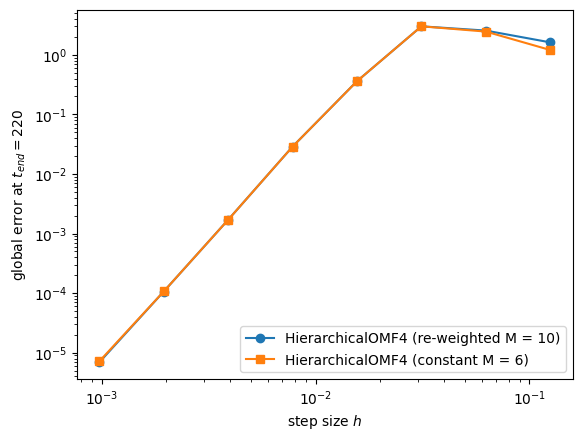

In [10]:
# load the results
data = np.load('HierarchicalOMF4_results.npz')
nstep_array = data['nstep_array']
global_error = data['global_error']
CPU_times = data['CPU_times']

plt.loglog(tspan[1]/nstep_array,global_error[0,:],marker='o',label=f'HierarchicalOMF4 (re-weighted M = 10)')
plt.loglog(tspan[1]/nstep_array,global_error[1,:],marker='s',label=f'HierarchicalOMF4 (constant M = 6)')
plt.legend()
plt.xlabel(r'step size $h$')
plt.ylabel(r'global error at $t_{end} = 220$')
matplot2tikz.save('HierarchicalOMF4_convergence.tex')

## Numerical results for COMP4

We perform numerical tests for the `COMP4` method that is only convergent of second order, but for sufficiently large multirate factor $M$ shows a computational order of four. 

As we have seen for the `HierarchicalOMF4` tests that the reweighting of the multirate factors results in a more efficient computational process, we perform the numerical tests only for reweighted multirate factors. This is mainly for visualization purposes and for the sake of time, but we performed some numerical simulations indicating that the qualitative scaling behavior is similar when choosing constant multirate factors.

In [ ]:
mr_array = np.array([10,50,100,250])
nstep_array = tspan[1] * np.sort(np.concatenate((np.array([10,50,100,250]),np.array([2**k for k in range(5,13)]))))
global_error = np.zeros((len(mr_array)+1,len(nstep_array)),dtype='float')
CPU_times = np.zeros((len(mr_array)+1,len(nstep_array)),dtype='float')

# for all multirate factors M in mr_array, we perform numerical simulations with the COMP4 method utilizing different step sizes h
np.seterr(over='raise') # "RuntimeWarning: overflow encountered in scalar power" then yields an error to terminate the integrator
it=0
for M in mr_array:
    print(f"M = {M}")
    for i in range(len(nstep_array)):
        print(i)
        start = time.process_time()
        try:
            if CPU_times[it,i-1] < 200:
                t,x = COMP4(x0,tspan,nstep_array[i],M,True)
                end = time.process_time()
                CPU_times[it,i] = end-start
                global_error[it,i] = np.linalg.norm(x_eval[:,-1] - x[:,-1])
            else:
                CPU_times[it,i] = 0
                global_error[it,i] = np.inf 
        except FloatingPointError:
            CPU_times[it,i] = 0
            global_error[it,i] = np.inf
    it+=1

# the following simulation considers step size-dependent multirate factors M(h) = 1/h
print('Now with M(h) = 1/h')
nsteps = tspan[1]*np.array([10,50,100,250,500,1000])
for i in range(len(nsteps)):
    print(i)
    start = time.process_time()
    try:
        t,x = COMP4(x0,tspan,nsteps[i],nsteps[i]/tspan[1],True)
        end = time.process_time()
        CPU_times[it,i] = end-start
        global_error[it,i] = np.linalg.norm(x_eval[:,-1] - x[:,-1])
    except FloatingPointError:
        CPU_times[it,i] = 0
        global_error[it,i] = np.inf

# store the results
np.savez('comp4_results.npz', 
         mr_array=mr_array, 
         nstep_array=nstep_array, 
         nsteps = nsteps,
         global_error=global_error, 
         CPU_times=CPU_times)
print("results saved in 'comp4_results.npz'")

M = 10
0
1
2
3
4
5
6
7
8
9
10
11
M = 50
0
1
2
3
4
5
6
7
8
9
10
11
M = 100
0
1
2
3
4
5
6
7
8
9
10
11
M = 250
0
1
2
3
4
5
6
7
8
9
10
11
Now with M(h) = 1/h
0
1
2
3
4
5
6
7
8
9
10
11
results saved in 'comp4_results.npz'


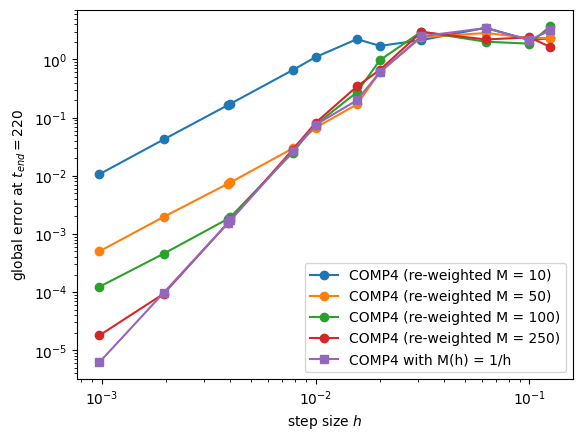

In [11]:
# load the results
data = np.load('comp4_results.npz')
mr_array = data['mr_array']
nstep_array = data['nstep_array']
global_error = data['global_error']
CPU_times = data['CPU_times']

# plot the results
it=0
for M in mr_array:
    plt.loglog(tspan[1]/nstep_array,global_error[it,:],marker='o',label=f'COMP4 (re-weighted M = {M})')
    it+=1
plt.loglog(tspan[1]/nstep_array,global_error[it,:],marker='s',label='COMP4 with M(h) = 1/h')
plt.legend()
plt.xlabel(r'step size $h$')
plt.ylabel(r'global error at $t_{end} = 220$')
matplot2tikz.save('COMP4_convergence.tex')


## Numerical results for YoshidaImpulse

The following results for the `YoshidaImpulse` method showcase the issues of composition schemes when the reweighting of the multirate factors is applied. 

In [14]:
nstep_array = np.array([tspan[1] * 2**k for k in range(3,13)]) #originally upper bound 11
global_error = np.zeros((2,len(nstep_array)),dtype='float')
CPU_times = np.zeros((2,len(nstep_array)),dtype='float')

np.seterr(over='raise') # "RuntimeWarning: overflow encountered in scalar power" then yields an error to terminate the integrator


for i in range(len(nstep_array)):
    start = time.process_time()
    try:
        t,x = YoshidaImpulse(x0,tspan,nstep_array[i],6,True)
        end = time.process_time()
        CPU_times[0,i] = end-start
        global_error[0,i] = np.linalg.norm(x_eval[:,-1] - x[:,-1])
    except FloatingPointError:
        CPU_times[0,i] = 0 
        global_error[0,i] = np.inf

for i in range(len(nstep_array)):
    start = time.process_time()
    try:
        t,x = YoshidaImpulse(x0,tspan,nstep_array[i],6,False)
        end = time.process_time()
        CPU_times[1,i] = end-start
        global_error[1,i] = np.linalg.norm(x_eval[:,-1] - x[:,-1])
    except FloatingPointError:
        CPU_times[1,i] = 0
        global_error[1,i] = np.inf

# store the results
np.savez('YoshidaImpulse_results.npz',  
         nstep_array=nstep_array, 
         global_error=global_error, 
         CPU_times=CPU_times)
print("results saved in 'YoshidaImpulse_results.npz'")

results saved in 'YoshidaImpulse_results.npz'


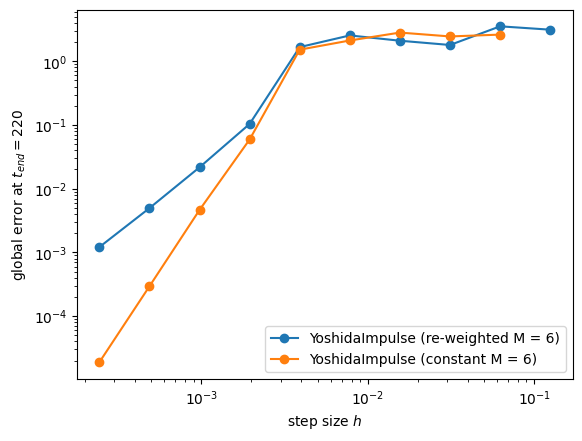

In [12]:
# load the results
data = np.load('YoshidaImpulse_results.npz')
nstep_array = data['nstep_array']
global_error = data['global_error']
CPU_times = data['CPU_times']

# plot the results
plt.loglog(tspan[1]/nstep_array,global_error[0,:],marker='o',label=f'YoshidaImpulse (re-weighted M = 6)')
plt.loglog(tspan[1]/nstep_array,global_error[1,:],marker='o',label=f'YoshidaImpulse (constant M = 6)')
plt.legend()
plt.xlabel(r'step size $h$')
plt.ylabel(r'global error at $t_{end} = 220$')
matplot2tikz.save('YoshidaImpulse_convergence.tex')

## Work-precision diagram

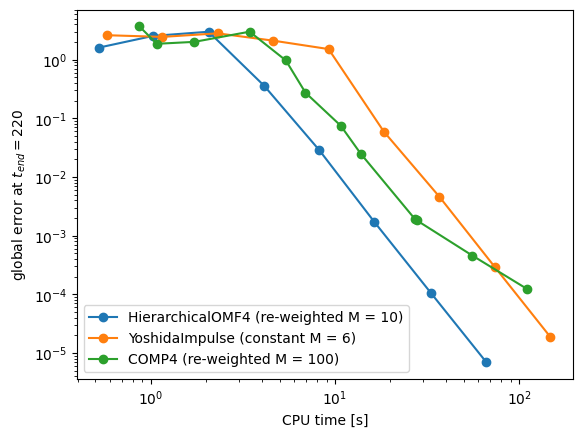

In [13]:
data = np.load('HierarchicalOMF4_results.npz')
nstep_array = data['nstep_array']
global_error = data['global_error']
CPU_times = data['CPU_times']
plt.loglog(CPU_times[0,:],global_error[0,:],marker='o',label=f'HierarchicalOMF4 (re-weighted M = 10)')

data = np.load('YoshidaImpulse_results.npz')
nstep_array = data['nstep_array']
global_error = data['global_error']
CPU_times = data['CPU_times']
plt.loglog(CPU_times[1,:],global_error[1,:],marker='o',label=f'YoshidaImpulse (constant M = 6)')

data = np.load('comp4_results.npz')
mr_array = data['mr_array']
nstep_array = data['nstep_array']
global_error = data['global_error']
CPU_times = data['CPU_times']
plt.loglog(CPU_times[2,:],global_error[2,:],marker='o',label=f'COMP4 (re-weighted M = {mr_array[2]})')

plt.legend()
plt.xlabel(r'CPU time [s]')
plt.ylabel(r'global error at $t_{end} = 220$')
matplot2tikz.save('FPU_work-precision.tex')

## Investigations of the adiabatic invariant

We consider the `HierarchicalOMF4` scheme as this is the most efficient integrator variant according to the work-precision diagram above.

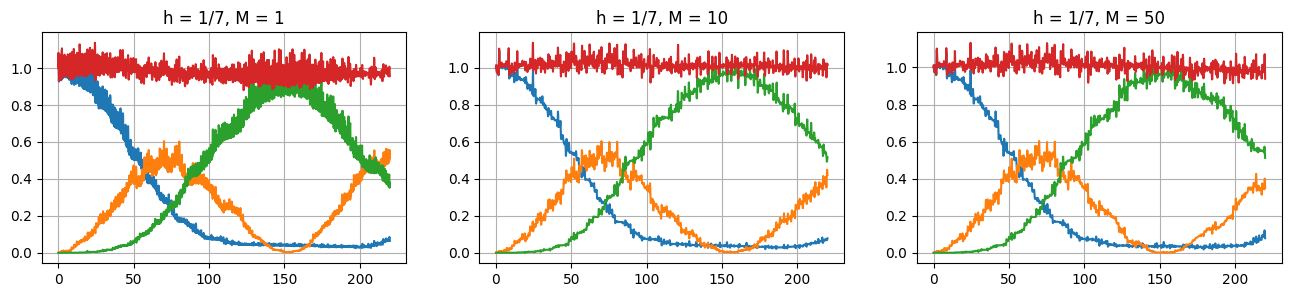

In [46]:
nstep_array = np.array([1540]) # nsteps corresponding to step sizes 1/6
mr_factors = np.array([1,10,50])


fig, axes = plt.subplots(1, 3, figsize=(16, 3))
axes = axes.flatten()   # damit wir mit axes[k] zugreifen können

for k, M in enumerate(mr_factors):
    for i in range(len(nstep_array)):
        ax = axes[3*i+k]   # aktuelles Subplot auswählen
        t, x = HierarchicalOMF4(x0, tspan, nstep_array[i], M, True)

        I1 = 0.5*x[m,:]**2 + omega**2/2 * x[3*m,:]**2
        I2 = 0.5*x[m+1,:]**2 + omega**2/2 * x[3*m+1,:]**2
        I3 = 0.5*x[m+2,:]**2 + omega**2/2 * x[3*m+2,:]**2
        I  = I1 + I2 + I3

        ax.plot(t, I1, label="I1")
        ax.plot(t, I2, label="I2")
        ax.plot(t, I3, label="I3")
        ax.plot(t, I,  label="I")
        ax.set_title(f"h = 1/7, M = {M}")
        ax.grid(True)

matplot2tikz.save('FPU_osc_energy.tex')

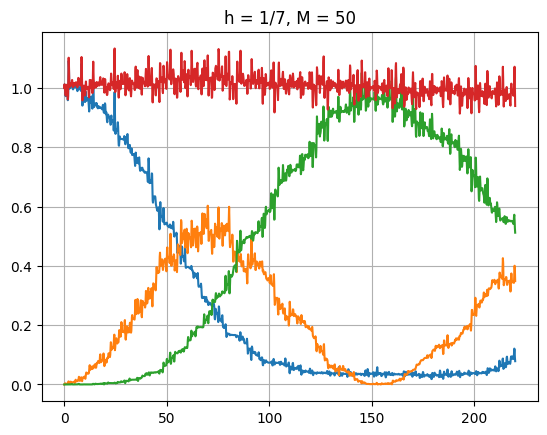

In [50]:
nstep_array = np.array([1540]) # nsteps corresponding to step sizes 1/6
mr_factors = np.array([50])

for k, M in enumerate(mr_factors):
    for i in range(len(nstep_array)):
        ax = axes[3*i+k]   # aktuelles Subplot auswählen
        t, x = HierarchicalOMF4(x0, tspan, nstep_array[i], M, True)

        I1 = 0.5*x[m,:]**2 + omega**2/2 * x[3*m,:]**2
        I2 = 0.5*x[m+1,:]**2 + omega**2/2 * x[3*m+1,:]**2
        I3 = 0.5*x[m+2,:]**2 + omega**2/2 * x[3*m+2,:]**2
        I  = I1 + I2 + I3

        plt.plot(t, I1, label="I1")
        plt.plot(t, I2, label="I2")
        plt.plot(t, I3, label="I3")
        plt.plot(t, I,  label="I")
        plt.title(f"h = 1/7, M = {M}")
        plt.grid(True)

matplot2tikz.save('FPU_osc_energy50.tex')